**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.feature_engineering.ChemicalFeatureEngineering import ChemicalFeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.bags_compositions import ALL_SAMPLES
from config.elements_coefficients import RESISTIVITY_FACTORS, ENRICHMENT_FACTORS
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()
chfe = ChemicalFeatureEngineering(
    all_samples=ALL_SAMPLES,
    resistivity_factors=RESISTIVITY_FACTORS,
    enrichment_factors=ENRICHMENT_FACTORS,
)



## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "IRI-test-all-data"
SCHEMA_DATE = "190826"
VARIABLE = "iacs"

# ---- Paths ----
FILE_NAME = f"dataset_annealing_{VARIABLE}.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = f"annealing_{VARIABLE}"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["initial_diameter", "IRI", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 1200

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.0 Chemical data

In [4]:
ANNEALING_SCHEMA_DATE = "190826"
SN_SCHEMA_DATE = "190826"


FILE_NAME_SN_COMPOSITION = f"serial-number-encoding_{SN_SCHEMA_DATE}.csv"
FILE_NAME_SCHEMA_DATA = f"schema_annealing_essays_{ANNEALING_SCHEMA_DATE}.csv"

FEATURES_TO_SELECT = [
    "experiment_id",
    "material_reference",
    "purity",
    "initial_diameter",
    "temperature",
    "time",
    "iacs",
    "tensile_strength",
    "elongation",
    "iacs_final",
    "tensile_strength_final",
    "elongation_final",
]

In [5]:
df_sn = pd.read_csv(os.path.join(varv.PATHS.data_structured, FILE_NAME_SN_COMPOSITION))
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_nnan = df_raw.dropna(how="all")
df_feat = df_nnan[FEATURES_TO_SELECT]
df_iri = chfe.add_features(df_feat, df_sn.drop(columns=["Sanity_check_Total"]))

In [6]:
df_iri

,experiment_id,material_reference,purity,initial_diameter,temperature,time,iacs,tensile_strength,elongation,iacs_final,tensile_strength_final,elongation_final,IRI,GBEI
0,ANE_SN010_CD1_RS1_WP1_202602171500-1,C14500,99.9000,1.900000,623.0,30.0,88.260,NaN,NaN,88.350000,NaN,NaN,1.300000,0.489800
1,ANE_SN010_CD1_RS1_WP1_202602171430-1,C14500,99.9000,1.900000,623.0,60.0,88.260,NaN,NaN,88.655000,NaN,NaN,1.300000,0.489800
2,ANE_SN010_CD1_RS1_WP1_202602171400-1,C14500,99.9000,1.900000,623.0,90.0,88.260,NaN,NaN,88.800000,NaN,NaN,1.300000,0.489800
4,ANE_SN011_CD1_RS1_WP1_202602181507-1,Cu-ETP,99.9000,2.160000,573.0,30.0,99.825,391.690000,4.90%,102.340000,249.783315,48.60%,0.195105,0.001038
5,ANE_SN011_CD1_RS1_WP1_202603301900-1,Cu-ETP,99.9000,2.182333,573.0,30.0,99.390,387.595254,6.02%,102.230000,255.008013,56.21%,0.195105,0.001038
7,ANE_SN011_CD1_RS1_WP1_202603311135-1,Cu-ETP,99.9000,2.182333,588.0,30.0,99.390,387.595254,6.02%,101.346667,NaN,NaN,0.195105,0.001038
8,ANE_SN011_CD1_RS1_WP1_202604031750-1,Cu-ETP,99.9000,2.191700,573.0,30.0,99.230,404.662322,3.53%,101.355000,NaN,NaN,0.195105,0.001038
9,ANE_SN011_CD1_RS1_WP1_202604031750-2,Cu-ETP,99.9000,2.196300,573.0,30.0,98.720,411.951845,3.27%,101.480000,NaN,NaN,0.195105,0.001038
11,NaN,Cu-T2,99.9000,1.200000,523.0,30.0,97.710,431.580000,0.94%,100.290000,247.080000,20.15%,0.233275,0.002674
12,NaN,Cu-T2,99.9000,1.200000,523.0,60.0,97.710,431.580000,0.94%,100.420000,242.210000,22.04%,0.233275,0.002674


## 2.1 Schema data

In [7]:
df, df_val = proc.process_annealing_iacs(
    features=FEATURES,
    target=TARGET,
    df_schema=df_iri,
)

In [8]:
df

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
3,2.160000,0.195105,99.9000,99.825,573.0,30.0,102.340000
4,2.182333,0.195105,99.9000,99.390,573.0,30.0,102.230000
5,2.182333,0.195105,99.9000,99.390,588.0,30.0,101.346667
6,2.191700,0.195105,99.9000,99.230,573.0,30.0,101.355000
7,2.196300,0.195105,99.9000,98.720,573.0,30.0,101.480000
8,1.200000,0.233275,99.9000,97.710,523.0,30.0,100.290000
9,1.200000,0.233275,99.9000,97.710,523.0,60.0,100.420000
10,1.200000,0.233275,99.9000,97.710,523.0,90.0,100.290000
11,1.200000,0.233275,99.9000,97.710,573.0,30.0,101.350000
12,1.200000,0.233275,99.9000,97.710,573.0,60.0,101.350000


## 2.2 Validation data

In [9]:
df_val

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
27,1.2000,0.402535,99.9800,102.70,523.0,30.0,102.235
16,1.2000,0.233275,99.9000,97.71,623.0,90.0,100.550
11,1.2000,0.233275,99.9000,97.71,573.0,30.0,101.350
28,1.2000,0.402535,99.9800,102.70,523.0,60.0,103.200
7,2.1963,0.195105,99.9000,98.72,573.0,30.0,101.480
43,2.0000,0.462318,99.7260,95.61,723.0,60.0,102.480
22,1.2000,0.195105,99.9000,101.22,523.0,60.0,104.865
42,2.0000,0.720778,99.6675,97.70,723.0,60.0,100.870


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [10]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.59 GB / 31.57 GB (24.0%)
Disk Space Avail:   694.31 GB / 932.08 GB (74.5%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\IRI-test-all-data\model_a"
Train Data Rows:    41
Train Data Columns: 6
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Lab

In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.656909,root_mean_squared_error,0.073048,14.540432,0.000000,0.013422,2,True,107
1,NeuralNetTorch_r30_BAG_L1,-0.704836,root_mean_squared_error,0.030216,6.871820,0.030216,6.871820,1,True,26
2,NeuralNetFastAI_r134_BAG_L1,-0.760561,root_mean_squared_error,0.042832,7.655190,0.042832,7.655190,1,True,55
3,NeuralNetFastAI_r102_BAG_L1,-0.767588,root_mean_squared_error,0.038487,7.202081,0.038487,7.202081,1,True,20
4,NeuralNetFastAI_r127_BAG_L1,-0.777066,root_mean_squared_error,0.034979,7.174897,0.034979,7.174897,1,True,89
...,...,...,...,...,...,...,...,...,...,...
102,LightGBM_r96_BAG_L1,-1.894881,root_mean_squared_error,0.003827,1.335197,0.003827,1.335197,1,True,15
103,LightGBM_r130_BAG_L1,-1.894881,root_mean_squared_error,0.006119,1.272338,0.006119,1.272338,1,True,27
104,LightGBM_r94_BAG_L1,-1.894881,root_mean_squared_error,0.007146,1.261117,0.007146,1.261117,1,True,57
105,ExtraTrees_r4_BAG_L1,-1.902170,root_mean_squared_error,0.040986,0.537006,0.040986,0.537006,1,True,62


In [12]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.656909,root_mean_squared_error,0.073048,14.540432,0.000000,0.013422,2,True,107
1,NeuralNetTorch_r30_BAG_L1,-0.704836,root_mean_squared_error,0.030216,6.871820,0.030216,6.871820,1,True,26
2,NeuralNetFastAI_r134_BAG_L1,-0.760561,root_mean_squared_error,0.042832,7.655190,0.042832,7.655190,1,True,55
3,NeuralNetFastAI_r102_BAG_L1,-0.767588,root_mean_squared_error,0.038487,7.202081,0.038487,7.202081,1,True,20
4,NeuralNetFastAI_r127_BAG_L1,-0.777066,root_mean_squared_error,0.034979,7.174897,0.034979,7.174897,1,True,89
...,...,...,...,...,...,...,...,...,...,...
102,LightGBM_r96_BAG_L1,-1.894881,root_mean_squared_error,0.003827,1.335197,0.003827,1.335197,1,True,15
103,LightGBM_r130_BAG_L1,-1.894881,root_mean_squared_error,0.006119,1.272338,0.006119,1.272338,1,True,27
104,LightGBM_r94_BAG_L1,-1.894881,root_mean_squared_error,0.007146,1.261117,0.007146,1.261117,1,True,57
105,ExtraTrees_r4_BAG_L1,-1.902170,root_mean_squared_error,0.040986,0.537006,0.040986,0.537006,1,True,62


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [13]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpxyia8zpj
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpxyia8zpj\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpxyia8zpj\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,5 months and 7 days
H2O_cluster_name:,H2O_from_python_fmfoa_b3luo6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.984 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
15:53:43.328: AutoML: XGBoost is not available; skipping it.


15:53:43.753: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 41.0.

███████████████████████████████████████████████████████████████| (done) 100%


In [39]:
aml_h2o.leaderboard

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260819_155343_model_3,0.809201,0.654807,0.616899,0.0079118,0.654807
GBM_grid_1_AutoML_1_20260819_155343_model_4532,0.821074,0.674162,0.637679,0.00803318,0.674162
GBM_grid_1_AutoML_1_20260819_155343_model_1318,0.833939,0.695455,0.619449,0.00814461,0.695455
GBM_grid_1_AutoML_1_20260819_155343_model_917,0.840262,0.70604,0.62588,0.00820457,0.70604
GBM_grid_1_AutoML_1_20260819_155343_model_97,0.840622,0.706645,0.6394,0.00821976,0.706645
GBM_grid_1_AutoML_1_20260819_155343_model_3351,0.842398,0.709634,0.647802,0.00823602,0.709634
GBM_grid_1_AutoML_1_20260819_155343_model_4905,0.846691,0.716885,0.624377,0.00827512,0.716885
GBM_grid_1_AutoML_1_20260819_155343_model_5474,0.847762,0.7187,0.647195,0.00827719,0.7187
GBM_grid_1_AutoML_1_20260819_155343_model_914,0.848686,0.720267,0.617357,0.00829642,0.720267
GBM_grid_1_AutoML_1_20260819_155343_model_86,0.84936,0.721413,0.640308,0.00830991,0.721413


In [14]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [40]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(41,)  any NaN? False


## 4.1 fast check on big residuals

In [43]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
)

df_verification.sort_values(by="residual", ascending=False)
# 

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final,iacs_final_pred,residual
39,2.000000,0.454239,99.9558,97.400,573.0,30.0,98.960000,100.866142,1.906142
25,1.200000,0.402535,99.9800,102.700,573.0,60.0,100.785000,102.604324,1.819324
38,0.800000,0.419799,99.9740,97.565,673.0,30.0,101.180000,99.630913,1.549087
30,2.000000,0.419799,99.9740,99.650,673.0,30.0,102.675000,101.569641,1.105359
31,0.800000,0.419799,99.9740,97.565,723.0,60.0,98.500000,99.401993,0.901993
24,1.200000,0.402535,99.9800,102.700,573.0,30.0,103.295000,102.458992,0.836008
4,2.182333,0.195105,99.9000,99.390,573.0,30.0,102.230000,101.440811,0.789189
42,2.000000,0.720778,99.6675,97.700,723.0,60.0,100.870000,101.650330,0.780330
16,1.200000,0.233275,99.9000,97.710,623.0,90.0,100.550000,101.315346,0.765346
11,1.200000,0.233275,99.9000,97.710,573.0,30.0,101.350000,100.669525,0.680475


In [17]:
df[residuals_oof.abs() > 2]

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final


In [18]:
mu_oof[residuals_oof.abs() > 2]

Series([], Name: iacs_final, dtype: float32)

## 4.2 Recovering weights 

In [19]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (106, 41)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1', 'CatBoost_r9_BAG_L1', 'LightGBM_r96_BAG_L1', 'NeuralNetTorch_r22_BAG_L1', 'XGBoost_r33_BAG_L1', 'ExtraTrees_r42_BAG_L1', 'CatBoost_r137_BAG_L1', 'NeuralNetFastAI_r102_BAG_L1', 'CatBoost_r13_BAG_L1', 'RandomForest_r195_BAG_L1', 'LightGBM_r188_BAG_L1', 'NeuralNetFastAI_r145_BAG_L1', 'XGBoost_r89_BAG_L1', 'NeuralNetTorch_r30_BAG_L1', 'LightGBM_r130_BAG_L1', 'NeuralNetTorch_r86_BAG_L1', 'CatBoost_r50_BAG_L1', 'NeuralNetFastAI_r11_BAG_L1', 'XGBoost_r194_BAG_L1', 'ExtraTrees_r172_BAG_L1', 'CatBoost_r69_BAG_L1', 'NeuralNetFastAI_r103_BAG_L1', 'NeuralNetTorch_r14_BAG_L1', 'LightGBM_r161_BAG_L1', 'NeuralNetFastAI_r143_BA

In [20]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000005  (OK)

Non-zero weights:
  NeuralNetTorch_r30_BAG_L1       0.6000
  NeuralNetFastAI_r134_BAG_L1     0.4000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [21]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    4.100000e+01
mean     1.411437e-06
std      1.038136e-06
min      3.067298e-08
25%      6.336925e-07
50%      1.064466e-06
75%      2.176860e-06
max      4.588321e-06
Name: iacs_final, dtype: float64

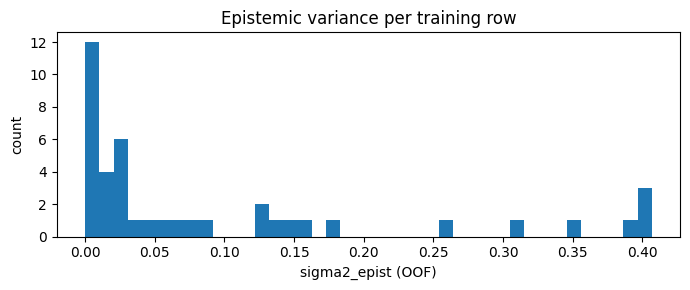

In [22]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [23]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    41.000000
mean      0.374161
std       0.255557
min       0.062592
25%       0.181808
50%       0.306686
75%       0.497421
max       1.160431
Name: iacs_final, dtype: float64

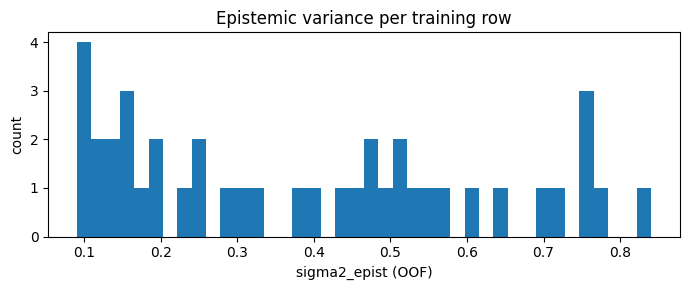

In [24]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [25]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 41
  n_truncated          = 14
  pct_truncated        = 34.146341463414636
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 3.6256410358082536
  r_tilde_sq_mean      = 0.36720009827222305
  r_tilde_sq_median    = 0.03773829292594642


In [26]:
r_tilde_sq

array([0.03773829, 0.61981742, 0.09265324, 0.        , 0.        ,
       0.00997222, 0.        , 0.20527768, 0.43463495, 0.30771543,
       0.        , 0.13502832, 0.        , 0.32779414, 0.42899803,
       0.03423184, 0.04374587, 0.03116534, 0.        , 0.01282455,
       0.        , 0.57505861, 2.91590176, 0.03046461, 0.        ,
       0.02037172, 0.12327595, 0.82252023, 0.73813875, 0.09698022,
       0.        , 0.        , 0.        , 0.        , 0.32920003,
       2.08654397, 3.62564104, 0.        , 0.        , 0.57953233,
       0.38997747])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [27]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.62 GB / 31.57 GB (11.5%)
Disk Space Avail:   693.69 GB / 932.08 GB (74.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\IRI-test-all-data\model_b"
Train Data Rows:    41
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (1.2880313859503394, -13.815510557964274, -5.815, 5.97

In [28]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-5.796154,root_mean_squared_error,0.034007,7.187078,0.000000,0.006000,2,True,10
1,NeuralNetTorch_BAG_L1,-5.796154,root_mean_squared_error,0.034007,7.181079,0.034007,7.181079,1,True,8
2,LightGBMXT_BAG_L1,-5.932674,root_mean_squared_error,0.004003,1.356533,0.004003,1.356533,1,True,1
3,LightGBM_BAG_L1,-5.932674,root_mean_squared_error,0.005352,2.147758,0.005352,2.147758,1,True,2
4,NeuralNetFastAI_BAG_L1,-5.951465,root_mean_squared_error,0.040026,8.064340,0.040026,8.064340,1,True,6
5,CatBoost_BAG_L1,-5.951814,root_mean_squared_error,0.006001,2.506497,0.006001,2.506497,1,True,4
6,XGBoost_BAG_L1,-5.961558,root_mean_squared_error,0.012504,1.163220,0.012504,1.163220,1,True,7
7,LightGBMLarge_BAG_L1,-5.981561,root_mean_squared_error,0.003006,1.320763,0.003006,1.320763,1,True,9
8,RandomForestMSE_BAG_L1,-7.719049,root_mean_squared_error,0.071537,0.646237,0.071537,0.646237,1,True,3
9,ExtraTreesMSE_BAG_L1,-7.783008,root_mean_squared_error,0.041521,0.470526,0.041521,0.470526,1,True,5


In [29]:
predictor_b.predict_oof()  

3    -5.861711
4    -3.254819
5    -6.238297
6    -6.241096
7    -6.581645
8    -5.738316
9    -5.427225
10   -5.512045
11   -6.029695
12   -5.956926
13   -6.654512
14   -5.960798
15   -5.888800
16   -4.367223
17   -6.657188
18   -5.951334
19   -3.520524
20   -6.318548
21   -4.894164
22   -6.247264
23   -6.517813
24   -5.910269
25   -5.889945
26   -5.833822
27   -6.372910
28   -3.409572
29   -6.344190
30   -6.288369
31   -6.263717
32   -5.962647
33   -6.292421
34   -6.341152
35   -6.131033
36   -5.619882
37   -6.085202
38   -6.590370
39   -6.636132
40   -5.708302
41   -6.122551
42   -1.728450
43   -6.206190
Name: log_r_tilde_sq, dtype: float32

In [30]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
3,0.199497,-5.861711,0.002061,99.825,102.340000
4,0.789189,-3.254819,0.003002,99.390,102.230000
5,-0.325246,-6.238297,0.013132,99.390,101.346667
6,-0.189449,-6.241096,0.042258,99.230,101.355000
7,0.192730,-6.581645,0.070376,98.720,101.480000
8,-0.173112,-5.738316,0.019995,97.710,100.290000
9,-0.159010,-5.427225,0.026445,97.710,100.420000
10,-0.461678,-5.512045,0.007869,97.710,100.290000
11,0.680475,-6.029695,0.028411,97.710,101.350000
12,0.585687,-5.956926,0.035314,97.710,101.350000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [31]:
df[TARGET].var()

np.float64(3.5472086954235054)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [32]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.317073,-0.182927
1,0.80,0.536585,-0.263415
2,0.90,0.658537,-0.241463
3,0.95,0.682927,-0.267073


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [33]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.9811

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.560976,0.060976
1,0.80,0.756098,-0.043902
2,0.90,0.926829,0.026829
3,0.95,0.951220,0.001220


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [34]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.50200835e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.49879323e-06,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.72031988e-07,
       0.00000000e+00, 5.99998222e-01, 0.00000000e+00, 3.96109399e-08,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.25526670e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.99997262e-01, 0.00000000e+00,
      

In [35]:
len(base_model_names)
len(weights)

106

In [36]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 0.4393, 'mae': 0.4041, 'mape': 0.396, 'r2': 0.8887}
coverage: {0.5: 0.25, 0.8: 0.625, 0.9: 1.0, 0.95: 1.0}


In [37]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

KeyError: "Missing features: ['IRI']"

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [ ]:
df.head(5)

,initial_diameter,purity,iacs,temperature,time,iacs_final
3,2.160000,99.9,99.825,573.0,30.0,102.340000
4,2.182333,99.9,99.390,573.0,30.0,102.230000
5,2.182333,99.9,99.390,588.0,30.0,101.346667
6,2.191700,99.9,99.230,573.0,30.0,101.355000
7,2.196300,99.9,98.720,573.0,30.0,101.480000


In [ ]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,102.160878,0.105908,0.036165,0.825059,0.908327,102.160881,1.0,102.158136,0.904028,8.870360e-04
1,101.772344,0.013187,0.036165,0.286599,0.535350,101.772346,1.0,101.772344,0.535350,8.245811e-10
2,101.781136,0.012804,0.036165,0.284378,0.533271,101.781136,1.0,101.781136,0.533271,7.895661e-10
3,101.688712,0.011692,0.036165,0.277919,0.527180,101.688713,1.0,101.688712,0.527180,1.680623e-10
4,101.439534,0.019720,0.036165,0.324539,0.569683,101.439537,1.0,101.439534,0.569683,2.053482e-10


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [ ]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\notebook_170826\artifacts.pkl


In [ ]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\notebook_170826\global_config.txt


In [ ]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  0.718913  0.570951  0.562930  0.853425
1          H2O AutoML (leader)  0.871089  0.675846  0.665631  0.784805
Saved to: ../../models/annealing_iacs\notebook_170826


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [ ]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['initial_diameter', 'purity', 'iacs', 'temperature', 'time']


In [ ]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,102.160878,0.105908,0.036165,0.825059,0.908327,102.160881,1.0,102.158136,0.904028,8.870360e-04
1,101.772344,0.013187,0.036165,0.286599,0.535350,101.772346,1.0,101.772344,0.535350,8.245811e-10
2,101.781136,0.012804,0.036165,0.284378,0.533271,101.781136,1.0,101.781136,0.533271,7.895661e-10
3,101.688712,0.011692,0.036165,0.277919,0.527180,101.688713,1.0,101.688712,0.527180,1.680623e-10
4,101.439534,0.019720,0.036165,0.324539,0.569683,101.439537,1.0,101.439534,0.569683,2.053482e-10


In [ ]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"initial_diameter": 2, "purity": 99.726, "iacs": 95.61, "temperature": 450+273, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 100.880


In [ ]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
